In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, accuracy_score,
    precision_score, recall_score, confusion_matrix, RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.inspection import permutation_importance

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DM1_PATH = "data/processed/classification_data.parquet"
DM2_PATH = "data/processed/clustering_data.parquet"

In [ ]:
df1 = pd.read_parquet(DM1_PATH)
print("DM1 shape:", df1.shape)
df1.info()

DM1 shape: (2643757, 11)
<class 'pandas.DataFrame'>
RangeIndex: 2643757 entries, 0 to 2643756
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   trip_distance      float64
 1   trip_duration_min  float64
 2   passenger_count    float64
 3   pickup_hour        int32  
 4   pickup_dayofweek   int32  
 5   is_weekend         int64  
 6   time_of_day        str    
 7   pickup_borough     str    
 8   dropoff_borough    str    
 9   fare_amount        float64
 10  high_tip           int64  
dtypes: float64(4), int32(2), int64(2), str(3)
memory usage: 268.3 MB


In [ ]:
print("Missing values before fill:\n", df1.isna().sum())

for c in ["pickup_borough", "dropoff_borough"]:
    df1[c] = df1[c].fillna("Outside_NYC")

print("\nClass balance of target `high_tip`:")
print(df1["high_tip"].value_counts(normalize=True).round(4))

Missing values before fill:
 trip_distance           0
trip_duration_min       0
passenger_count         0
pickup_hour             0
pickup_dayofweek        0
is_weekend              0
time_of_day             0
pickup_borough        374
dropoff_borough      9612
fare_amount             0
high_tip                0
dtype: int64

Class balance of target `high_tip`:
high_tip
1    0.7877
0    0.2123
Name: proportion, dtype: float64


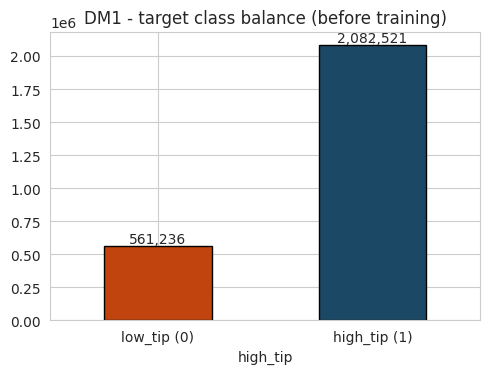

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
df1["high_tip"].value_counts().sort_index().plot(
    kind="bar", color=["#c1440e", "#1b4965"], edgecolor="black", ax=ax
)
ax.set_xticklabels(["low_tip (0)", "high_tip (1)"], rotation=0)
ax.set_title("DM1 - target class balance (before training)")
for i, v in enumerate(df1["high_tip"].value_counts().sort_index().values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

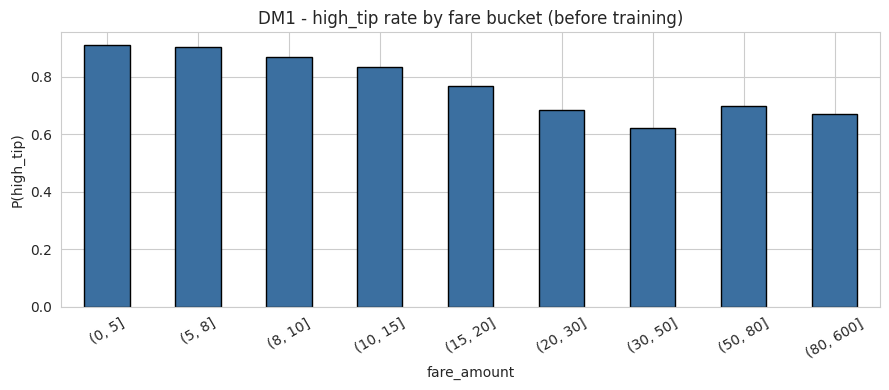

fare_amount
(0, 5]       0.909
(5, 8]       0.902
(8, 10]      0.869
(10, 15]     0.834
(15, 20]     0.766
(20, 30]     0.685
(30, 50]     0.622
(50, 80]     0.697
(80, 600]    0.670
Name: high_tip, dtype: float64


In [ ]:
fare_bins = pd.cut(df1["fare_amount"], [0, 5, 8, 10, 15, 20, 30, 50, 80, 600])
tip_by_fare = df1.groupby(fare_bins, observed=True)["high_tip"].mean()
fig, ax = plt.subplots(figsize=(9, 4))
tip_by_fare.plot(kind="bar", color="#3b6fa0", edgecolor="black", ax=ax)
ax.set_ylabel("P(high_tip)")
ax.set_title("DM1 - high_tip rate by fare bucket (before training)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()
print(tip_by_fare.round(3))

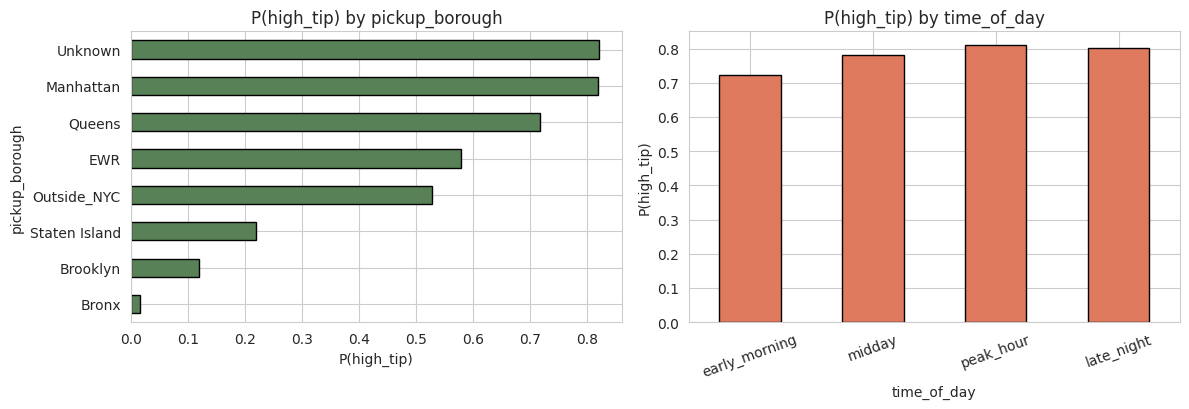

pickup_borough
Bronx            0.016
Brooklyn         0.120
Staten Island    0.220
Outside_NYC      0.529
EWR              0.579
Queens           0.718
Manhattan        0.820
Unknown          0.821
Name: high_tip, dtype: float64
time_of_day
early_morning    0.724
late_night       0.801
midday           0.781
peak_hour        0.810
Name: high_tip, dtype: float64


In [ ]:
tip_by_borough = df1.groupby("pickup_borough", observed=True)["high_tip"].mean().sort_values()
tip_by_tod = df1.groupby("time_of_day", observed=True)["high_tip"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
tip_by_borough.plot(kind="barh", color="#588157", edgecolor="black", ax=axes[0])
axes[0].set_title("P(high_tip) by pickup_borough")
axes[0].set_xlabel("P(high_tip)")

tip_by_tod.reindex(["early_morning", "midday", "peak_hour", "late_night"]).plot(
    kind="bar", color="#e07a5f", edgecolor="black", ax=axes[1]
)
axes[1].set_title("P(high_tip) by time_of_day")
axes[1].set_ylabel("P(high_tip)")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

print(tip_by_borough.round(3))
print(tip_by_tod.round(3))

In [ ]:
def engineer_dm1(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    X["speed_mph"] = (X["trip_distance"] / X["trip_duration_min"] * 60).clip(0, 80)
    X["fare_per_mile"] = (X["fare_amount"] / X["trip_distance"].replace(0, np.nan)).fillna(0).clip(0, 100)
    X["fare_per_min"] = (X["fare_amount"] / X["trip_duration_min"]).clip(0, 50)
    X["hour_sin"] = np.sin(2 * np.pi * X["pickup_hour"] / 24)
    X["hour_cos"] = np.cos(2 * np.pi * X["pickup_hour"] / 24)
    X["same_borough"] = (X["pickup_borough"] == X["dropoff_borough"]).astype(int)
    return X

NUM_COLS = ["trip_distance", "trip_duration_min", "passenger_count", "pickup_hour",
            "pickup_dayofweek", "is_weekend", "fare_amount",
            "speed_mph", "fare_per_mile", "fare_per_min", "hour_sin", "hour_cos", "same_borough"]
CAT_COLS = ["time_of_day", "pickup_borough", "dropoff_borough"]

y1 = df1["high_tip"]
X1 = df1.drop(columns=["high_tip"])

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, stratify=y1, random_state=RANDOM_STATE
)
X1_train = engineer_dm1(X1_train)
X1_test = engineer_dm1(X1_test)

print("Train:", X1_train.shape, "Test:", X1_test.shape)

Train: (2115005, 16) Test: (528752, 16)


In [ ]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X1_train, y1_train)
p_dummy = dummy.predict_proba(X1_test)[:, 1]

lr_pre = ColumnTransformer([
    ("num", StandardScaler(), NUM_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
])
lr_pipe = Pipeline([("pre", lr_pre), ("clf", LogisticRegression(max_iter=500, random_state=RANDOM_STATE))])

t0 = time.time()
lr_pipe.fit(X1_train, y1_train)
lr_fit_time = time.time() - t0
p_lr = lr_pipe.predict_proba(X1_test)[:, 1]
pred_lr = lr_pipe.predict(X1_test)

print(f"Logistic Regression trained in {lr_fit_time:.1f}s")

Logistic Regression trained in 10.5s


In [ ]:
ordenc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X1_train_enc = X1_train.copy()
X1_test_enc = X1_test.copy()
X1_train_enc[CAT_COLS] = ordenc.fit_transform(X1_train[CAT_COLS])
X1_test_enc[CAT_COLS] = ordenc.transform(X1_test[CAT_COLS])
cat_idx = [X1_train_enc.columns.get_loc(c) for c in CAT_COLS]

hgb = HistGradientBoostingClassifier(
    categorical_features=cat_idx,
    learning_rate=0.05,
    max_iter=500,
    max_leaf_nodes=63,
    l2_regularization=0.1,
    random_state=RANDOM_STATE,
)

t0 = time.time()
hgb.fit(X1_train_enc, y1_train)
hgb_fit_time = time.time() - t0
p_hgb = hgb.predict_proba(X1_test_enc)[:, 1]
pred_hgb = hgb.predict(X1_test_enc)

print(f"HistGradientBoosting trained in {hgb_fit_time:.1f}s")

HistGradientBoosting trained in 79.2s


In [ ]:
def clf_report(name, y_true, y_prob, y_pred, fit_time):
    return {
        "model": name,
        "fit_time_s": round(fit_time, 1),
        "AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }

results_dm1 = pd.DataFrame([
    clf_report("Dummy (majority class)", y1_test, p_dummy, dummy.predict(X1_test), 0.0),
    clf_report("Baseline - Logistic Regression", y1_test, p_lr, pred_lr, lr_fit_time),
    clf_report("Best - HistGradientBoosting", y1_test, p_hgb, pred_hgb, hgb_fit_time),
])
print(results_dm1.round(4).to_string(index=False))

                         model  fit_time_s    AUC  PR_AUC  Accuracy  Precision  Recall     F1
        Dummy (majority class)         0.0 0.5000  0.7877    0.7877     0.7877  1.0000 0.8813
Baseline - Logistic Regression        10.5 0.6825  0.8649    0.8231     0.8228  0.9883 0.8980
   Best - HistGradientBoosting        79.2 0.7165  0.8872    0.8384     0.8310  0.9978 0.9068


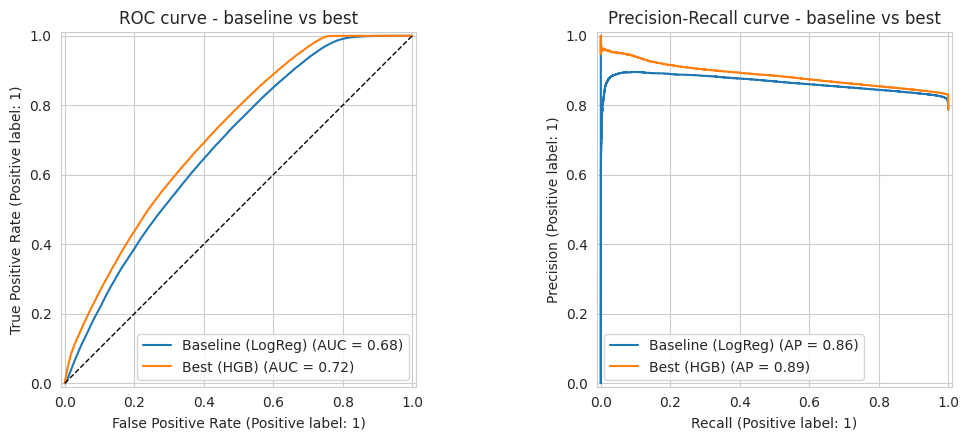

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
RocCurveDisplay.from_predictions(y1_test, p_lr, name="Baseline (LogReg)", ax=axes[0])
RocCurveDisplay.from_predictions(y1_test, p_hgb, name="Best (HGB)", ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_title("ROC curve - baseline vs best")

PrecisionRecallDisplay.from_predictions(y1_test, p_lr, name="Baseline (LogReg)", ax=axes[1])
PrecisionRecallDisplay.from_predictions(y1_test, p_hgb, name="Best (HGB)", ax=axes[1])
axes[1].set_title("Precision-Recall curve - baseline vs best")
plt.tight_layout()
plt.show()

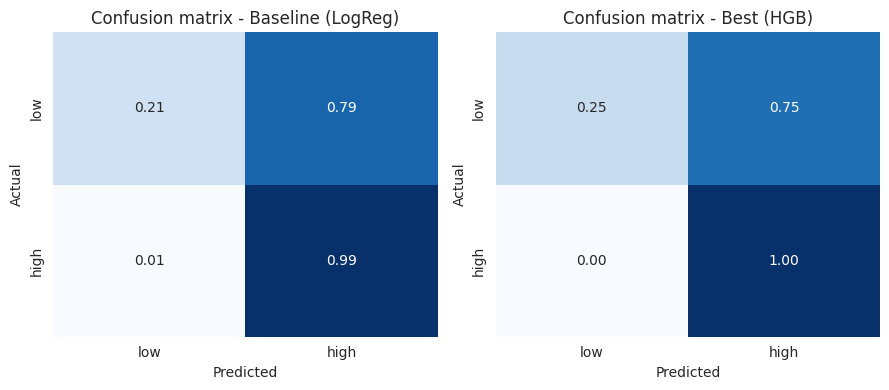

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, pred, name in zip(axes, [pred_lr, pred_hgb], ["Baseline (LogReg)", "Best (HGB)"]):
    cm = confusion_matrix(y1_test, pred, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", cbar=False,
                xticklabels=["low", "high"], yticklabels=["low", "high"], ax=ax)
    ax.set_title(f"Confusion matrix - {name}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

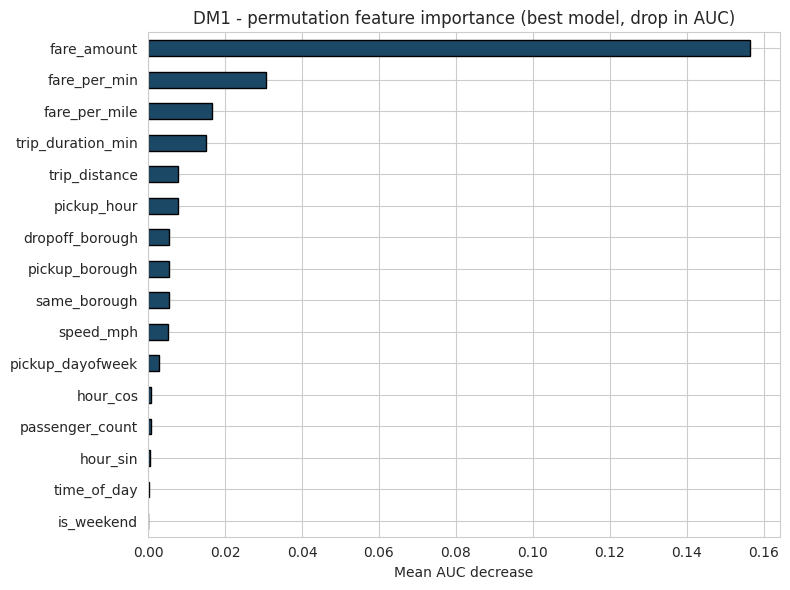

fare_amount          0.1564
fare_per_min         0.0307
fare_per_mile        0.0166
trip_duration_min    0.0151
trip_distance        0.0078
pickup_hour          0.0077
dropoff_borough      0.0055
pickup_borough       0.0054
same_borough         0.0053
speed_mph            0.0051
pickup_dayofweek     0.0027
hour_cos             0.0009
passenger_count      0.0007
hour_sin             0.0006
time_of_day          0.0002
is_weekend           0.0000
dtype: float64


In [ ]:
sample_idx = X1_test_enc.sample(60000, random_state=RANDOM_STATE).index
perm = permutation_importance(
    hgb, X1_test_enc.loc[sample_idx], y1_test.loc[sample_idx],
    n_repeats=5, random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=1,
)
imp = pd.Series(perm.importances_mean, index=X1_test_enc.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
imp.plot(kind="barh", color="#1b4965", edgecolor="black", ax=ax)
ax.set_title("DM1 - permutation feature importance (best model, drop in AUC)")
ax.set_xlabel("Mean AUC decrease")
plt.tight_layout()
plt.show()
print(imp.sort_values(ascending=False).round(4))

In [ ]:
print("Baseline AUC :", round(results_dm1.loc[1, 'AUC'], 4))
print("Best AUC     :", round(results_dm1.loc[2, 'AUC'], 4))
print("Absolute AUC gain over baseline:", round(results_dm1.loc[2, 'AUC'] - results_dm1.loc[1, 'AUC'], 4))
print("Absolute AUC gain over majority-class dummy:", round(results_dm1.loc[2, 'AUC'] - results_dm1.loc[0, 'AUC'], 4))

Baseline AUC : 0.6825
Best AUC     : 0.7165
Absolute AUC gain over baseline: 0.034
Absolute AUC gain over majority-class dummy: 0.2165


In [ ]:

df2 = pd.read_parquet(DM2_PATH)
print("DM2 shape:", df2.shape)
df2.info()

DM2 shape: (3886428, 7)
<class 'pandas.DataFrame'>
RangeIndex: 3886428 entries, 0 to 3886427
Data columns (total 7 columns):
 #   Column             Dtype  
---  ------             -----  
 0   trip_distance      float64
 1   trip_duration_min  float64
 2   pickup_hour        int32  
 3   pickup_dayofweek   int32  
 4   is_weekend         int64  
 5   pickup_borough     str    
 6   dropoff_borough    str    
dtypes: float64(2), int32(2), int64(1), str(2)
memory usage: 243.1 MB


Missing values before fill:
 trip_distance            0
trip_duration_min        0
pickup_hour              0
pickup_dayofweek         0
is_weekend               0
pickup_borough         494
dropoff_borough      15503
dtype: int64


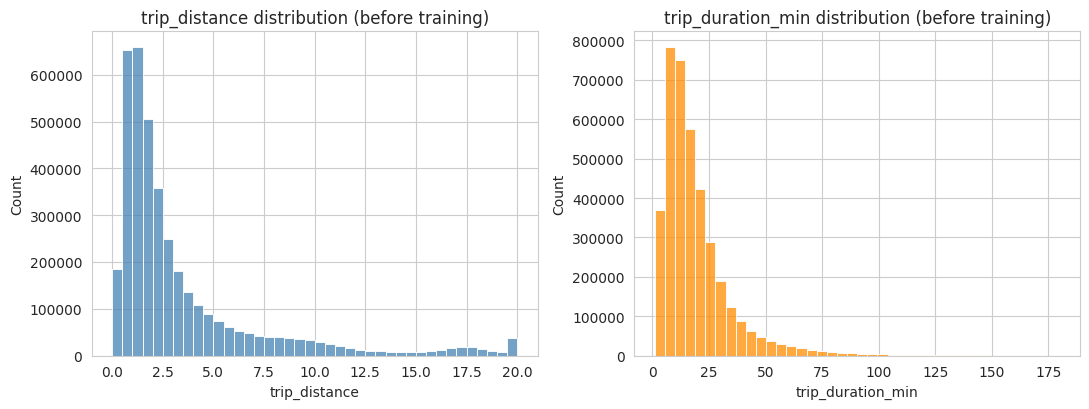


Origin-destination borough counts:
dropoff_borough  Bronx  Brooklyn   EWR  Manhattan  Outside_NYC  Queens  \
pickup_borough                                                           
Bronx             9875      3568     4      17558           75    3367   
Brooklyn          3849     76076    41      53295          215   18136   
EWR                  0         1     8          8            3       2   
Manhattan        28789    100570  6592    3118695         6579  102443   
Outside_NYC         18        18   123         72          197      62   
Queens            8026     54067   226     177546         8397   80229   
Staten Island        2       142     1         55            4      11   
Unknown             27       194    14       2440           33     273   

dropoff_borough  Staten Island  Unknown  
pickup_borough                           
Bronx                        2        0  
Brooklyn                   118        8  
EWR                          0        0  
Manhattan    

In [ ]:
print("Missing values before fill:\n", df2.isna().sum())
for c in ["pickup_borough", "dropoff_borough"]:
    df2[c] = df2[c].fillna("Outside_NYC")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.histplot(df2["trip_distance"].clip(upper=20), bins=40, color="steelblue", ax=axes[0])
axes[0].set_title("trip_distance distribution (before training)")
sns.histplot(df2["trip_duration_min"], bins=40, color="darkorange", ax=axes[1])
axes[1].set_title("trip_duration_min distribution (before training)")
plt.tight_layout()
plt.show()

od = pd.crosstab(df2["pickup_borough"], df2["dropoff_borough"])
print("\nOrigin-destination borough counts:")
print(od)

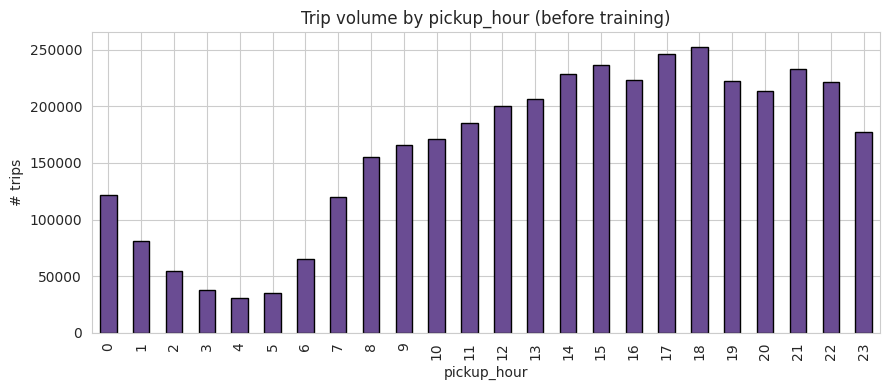

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
df2["pickup_hour"].value_counts().sort_index().plot(kind="bar", color="#6a4c93", edgecolor="black", ax=ax)
ax.set_title("Trip volume by pickup_hour (before training)")
ax.set_ylabel("# trips")
plt.tight_layout()
plt.show()

In [ ]:
NUM_BASE = ["trip_distance", "trip_duration_min", "pickup_hour", "pickup_dayofweek", "is_weekend"]

samp2 = df2.sample(200000, random_state=RANDOM_STATE).reset_index(drop=True)

base_pre = ColumnTransformer([("num", StandardScaler(), NUM_BASE)])
Xb = base_pre.fit_transform(samp2)

base_scores = {}
for k in range(3, 8):
    km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, batch_size=4096).fit(Xb)
    sil = silhouette_score(Xb, km.labels_, sample_size=25000, random_state=RANDOM_STATE)
    base_scores[k] = sil
print("Baseline silhouette by k:", {k: round(v, 4) for k, v in base_scores.items()})

k_base = max(base_scores, key=base_scores.get)
km_base = MiniBatchKMeans(n_clusters=k_base, random_state=RANDOM_STATE, n_init=10, batch_size=4096).fit(Xb)
labels_base = km_base.labels_
print(f"Baseline: chosen k={k_base}, silhouette={base_scores[k_base]:.4f}")

Baseline silhouette by k: {3: 0.4302, 4: 0.3287, 5: 0.3222, 6: 0.2884, 7: 0.3267}
Baseline: chosen k=3, silhouette=0.4302


In [19]:
samp2["cluster_base"] = labels_base
base_profile = samp2.groupby("cluster_base")[["trip_distance", "trip_duration_min", "pickup_hour", "is_weekend"]].mean()
base_profile["n_trips"] = samp2["cluster_base"].value_counts().sort_index()
print(base_profile.round(2))

              trip_distance  trip_duration_min  pickup_hour  is_weekend  \
cluster_base                                                              
0                      2.29              15.26        14.63         0.0   
1                      2.78              15.14        13.19         1.0   
2                     13.81              53.84        13.51         0.2   

              n_trips  
cluster_base           
0              121453  
1               59663  
2               18884  


In [ ]:
samp2b = samp2.drop(columns=["cluster_base"]).copy()
samp2b["hour_sin"] = np.sin(2 * np.pi * samp2b["pickup_hour"] / 24)
samp2b["hour_cos"] = np.cos(2 * np.pi * samp2b["pickup_hour"] / 24)
samp2b["dow_sin"] = np.sin(2 * np.pi * samp2b["pickup_dayofweek"] / 7)
samp2b["dow_cos"] = np.cos(2 * np.pi * samp2b["pickup_dayofweek"] / 7)

NUM_BEST = ["trip_distance", "trip_duration_min", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend"]
CAT_BEST = ["pickup_borough", "dropoff_borough"]

best_pre = ColumnTransformer([
    ("num", StandardScaler(), NUM_BEST),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_BEST),
])
Xbest = best_pre.fit_transform(samp2b)

best_scores = {}
for k in range(3, 9):
    km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, batch_size=4096).fit(Xbest)
    sil = silhouette_score(Xbest, km.labels_, sample_size=25000, random_state=RANDOM_STATE)
    dbi = davies_bouldin_score(Xbest.toarray() if hasattr(Xbest, "toarray") else Xbest, km.labels_)
    best_scores[k] = (sil, dbi)
print("Best-model silhouette/DBI by k:", {k: (round(s, 4), round(d, 4)) for k, (s, d) in best_scores.items()})

k_best = 5 
km_best = MiniBatchKMeans(n_clusters=k_best, random_state=RANDOM_STATE, n_init=10, batch_size=4096).fit(Xbest)
labels_best = km_best.labels_
sil_best = silhouette_score(Xbest, labels_best, sample_size=25000, random_state=RANDOM_STATE)
dbi_best = davies_bouldin_score(Xbest.toarray() if hasattr(Xbest, "toarray") else Xbest, labels_best)
print(f"Best model: k={k_best}, silhouette={sil_best:.4f}, DBI={dbi_best:.4f}")

Best-model silhouette/DBI by k: {3: (0.2373, 1.8242), 4: (0.2251, 1.6531), 5: (0.2054, 1.7488), 6: (0.2416, 1.4203), 7: (0.2422, 1.3413), 8: (0.241, 1.5881)}


Best model: k=5, silhouette=0.2054, DBI=1.7488


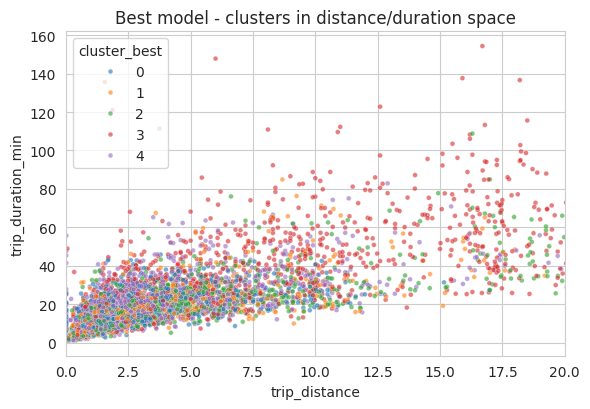

In [21]:
samp2b["cluster_best"] = labels_best
fig, ax = plt.subplots(figsize=(6, 4.2))
sns.scatterplot(
    data=samp2b.sample(8000, random_state=0),
    x="trip_distance", y="trip_duration_min", hue="cluster_best",
    palette="tab10", s=12, alpha=0.6, ax=ax,
)
ax.set_xlim(0, 20)
ax.set_title("Best model - clusters in distance/duration space")
plt.tight_layout()
plt.show()

In [ ]:
profile_best = samp2b.groupby("cluster_best").agg(
    n_trips=("trip_distance", "size"),
    avg_distance=("trip_distance", "mean"),
    avg_duration=("trip_duration_min", "mean"),
    pct_weekend=("is_weekend", "mean"),
    pct_pickup_manhattan=("pickup_borough", lambda s: (s == "Manhattan").mean()),
    pct_dropoff_outer_borough=("dropoff_borough", lambda s: (~s.isin(["Manhattan", "Outside_NYC", "Unknown"])).mean()),
    avg_pickup_hour=("pickup_hour", "mean"),
)
print(profile_best.round(3))

              n_trips  avg_distance  avg_duration  pct_weekend  \
cluster_best                                                     
0               40769         2.335        14.153        0.000   
1               27370         2.938        15.659        1.000   
2               35647         3.897        17.968        1.000   
3               38822         6.078        30.324        0.009   
4               57392         2.686        16.558        0.000   

              pct_pickup_manhattan  pct_dropoff_outer_borough  avg_pickup_hour  
cluster_best                                                                    
0                            0.937                      0.079           17.749  
1                            0.890                      0.116           12.151  
2                            0.844                      0.144           14.131  
3                            0.724                      0.218           10.767  
4                            0.914                 

In [ ]:
results_dm2 = pd.DataFrame([
    {"model": "Baseline - KMeans (raw numeric only)", "k": k_base,
     "silhouette": base_scores[k_base], "uses_spatial_features": False,
     "uses_cyclical_time": False},
    {"model": "Best - KMeans (cyclical time + borough one-hot)", "k": k_best,
     "silhouette": sil_best, "davies_bouldin": dbi_best,
     "uses_spatial_features": True, "uses_cyclical_time": True},
])
print(results_dm2.to_string(index=False))

                                          model  k  silhouette  uses_spatial_features  uses_cyclical_time  davies_bouldin
           Baseline - KMeans (raw numeric only)  3    0.430175                  False               False             NaN
Best - KMeans (cyclical time + borough one-hot)  5    0.205393                   True                True        1.748774


In [ ]:
print("Baseline silhouette:", round(base_scores[k_base], 4), "| clusters driven only by trip length/time")
print("Best silhouette    :", round(sil_best, 4), "| clusters additionally shaped by pickup/dropoff borough composition")

Baseline silhouette: 0.4302 | clusters driven only by trip length/time
Best silhouette    : 0.2054 | clusters additionally shaped by pickup/dropoff borough composition


##  KẾT QUẢ TÓM TẮT 
### DM1 — Classification: dự đoán `high_tip`

| Model | AUC | PR-AUC | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|---|---|
| Dummy (majority class) | 0.500 | 0.788 | 0.788 | 0.788 | 1.000 | 0.881 |
| **Baseline** — Logistic Regression | 0.683 | 0.865 | 0.823 | 0.823 | 0.988 | 0.898 |
| **Best** — HistGradientBoosting | **0.716** | **0.887** | **0.838** | **0.831** | **0.998** | **0.907** |


- **Δ AUC so với baseline:** +0.039 · **Δ so với dummy:** +0.216 → mô hình học được tín hiệu thật, không chỉ đoán theo lớp đa số (lớp `high_tip=1` chiếm 78.8%).
- **Feature quan trọng nhất** (permutation importance): `fare_amount`, `fare_per_mile`, `fare_per_min`, `pickup_borough` — khớp với EDA trước train (tip rate giảm dần khi fare tăng: từ ~91% ở fare ≤5$ xuống ~62–70% ở fare >30$; Manhattan/Queens có tip rate cao nhất ~0.72–0.82, Bronx/Brooklyn thấp nhất ~0.02–0.12).
- `pickup_dayofweek` / `is_weekend` **gần như không đóng góp** — khớp với phát hiện tip rate gần như không đổi theo thứ trong tuần (0.776–0.796).
- **Giới hạn:** AUC ~0.72 là trần hợp lý của bài toán — hành vi tip phụ thuộc nhiều yếu tố ngoài dữ liệu chuyến đi (thái độ tài xế, cảm nhận cá nhân khách hàng).

### DM2 — Clustering: phân cụm mẫu hình di chuyển

| Model | k | Silhouette | Davies-Bouldin |
|---|---|---|---|
| **Baseline** — KMeans (numeric thô) | 3 | **0.430** | — |
| **Best** — KMeans (cyclical time + one-hot borough) | 5 | 0.205 | 1.75 |

- Silhouette baseline cao hơn về mặt hình học **nhưng đây là hiện tượng ảo** do không gian đặc trưng ít chiều hơn (5 cột numeric thô) — cụm chỉ tách theo "chuyến ngắn/dài", không mang thông tin không gian.
- Cụm best-model có quãng đường/thời lượng lớn nhất (**6.08 mi / 30.3 phút**) có tỷ lệ trả khách ngoài Manhattan **21.8%** — cao gấp **~2.8×** so với cụm ngắn nhất (**7.9%**) → mô hình nắm được liên hệ thật giữa quãng đường và điểm đến, không chỉ tách theo độ dài chuyến.
- **Trade-off cần nêu rõ:** silhouette thấp hơn không đồng nghĩa mô hình "tệ hơn" — đây là đánh đổi giữa điểm số thống kê thuần túy (bị thổi phồng khi số chiều nhỏ) và tính diễn giải nghiệp vụ thực chất (phục vụ mục tiêu BO2 — điều phối xe theo khu vực/thời điểm).

### Kết luận chung

Ở cả hai bài toán, model phức tạp hơn (feature engineering + thuật toán mạnh hơn) khai thác được nhiều thông tin thực chất hơn baseline — dù benchmark thô không phải lúc nào cũng tăng đơn điệu (trường hợp DM2, silhouette giảm nhưng chất lượng diễn giải tăng). Đây là insight quan trọng cần đưa vào phần Evaluation của báo cáo, tránh chỉ nhìn một con số benchmark duy nhất để kết luận model nào "tốt hơn".
